In [33]:
import math
from pathlib import Path

import torch
from torch import nn
from torch.nn import functional as F
from torch.utils.data import DataLoader, Dataset

DATA_DIR = Path('shakespeare-dataset-main/text')
BLOCK_SIZE, BATCH_SIZE = 64, 64
DIM, MODEL_DIM, NUM_LAYERS, NUM_HEADS = 16, 128, 6, 4
DIFFUSION_STEPS = 1000
TRAIN_STEPS, LOG_EVERY = 10000, 200
PRIOR_WEIGHT, PRIOR_SAMPLES = 1.0, 1024
MMD_BANDWIDTHS = tuple(math.sqrt(DIM) * x for x in (0.25, 0.5, 1, 2, 4))

device = torch.device('mps' if torch.backends.mps.is_available()
                      else 'cuda' if torch.cuda.is_available() else 'cpu')
torch.manual_seed(7)
print(f'Using {device}')


Using mps


In [34]:
def clean_folger_text(raw):
    lines = raw.replace('\r\n', '\n').replace('\r', '\n').splitlines(keepends=True)
    return ''.join(lines[7:]).lstrip('\n')

paths = sorted(DATA_DIR.glob('*.txt'))
if not paths:
    raise FileNotFoundError(f'No .txt files in {DATA_DIR}')
text = '\n\n'.join(clean_folger_text(p.read_text(encoding='utf-8')) for p in paths)
chars = sorted(set(text))
stoi = {char: index for index, char in enumerate(chars)}
tokens = torch.tensor([stoi[c] for c in text], dtype=torch.long)

class CharacterBlocks(Dataset):
    def __len__(self): return len(tokens) // BLOCK_SIZE
    def __getitem__(self, index):
        start = index * BLOCK_SIZE
        return tokens[start:start + BLOCK_SIZE]

loader = DataLoader(CharacterBlocks(), batch_size=BATCH_SIZE, shuffle=True, drop_last=True)
print(f'Loaded {len(paths)} works | {len(tokens):,} characters | vocab={len(chars)}')


Loaded 42 works | 5,319,139 characters | vocab=84


In [35]:
class GaussianEmbedding(nn.Module):
    def __init__(self, vocab_size, dim):
        super().__init__()
        token_var = 0.05
        mean_var = 1.0 - token_var

        std_init = math.sqrt(token_var)
        raw_std_init = math.log(math.expm1(std_init))

        self.mu = nn.Parameter(torch.randn(vocab_size, dim) * math.sqrt(mean_var))
        self.raw_std = nn.Parameter(torch.full((vocab_size, dim), raw_std_init))
    @property
    def std(self):
        return F.softplus(self.raw_std)
    def sample(self, ids):
        mean = self.mu[ids]
        return mean + self.std[ids] * torch.randn_like(mean)
    def log_probs(self, vectors):
        std = self.std
        precision = std.square().reciprocal()
        weighted_means = self.mu * precision
        mahalanobis = (
            vectors.square() @ precision.T
            - 2 * (vectors @ weighted_means.T)
            + (self.mu.square() * precision).sum(-1)
        )
        log_density = -0.5 * mahalanobis - std.log().sum(-1)
        return F.log_softmax(log_density, dim=-1)

class SimpleGaussianDiffusionLM(nn.Module):
    def __init__(self, vocab_size):
        super().__init__()
        self.embedding = GaussianEmbedding(vocab_size, DIM)
        self.input_projection = nn.Linear(DIM, MODEL_DIM)
        self.position = nn.Embedding(BLOCK_SIZE, MODEL_DIM)

        frequencies = torch.exp(-math.log(10_000) * torch.arange(MODEL_DIM // 2) / (MODEL_DIM // 2))
        self.register_buffer('time_frequencies', frequencies)
        layer = nn.TransformerEncoderLayer(MODEL_DIM, NUM_HEADS, 512, 0.1, batch_first=True, norm_first=False, activation='gelu')
        self.transformer = nn.TransformerEncoder(layer, NUM_LAYERS)
        self.final_norm, self.x0_head = nn.LayerNorm(MODEL_DIM), nn.Linear(MODEL_DIM, DIM)
    def forward(self, x_t, timesteps):
        if timesteps.shape != x_t.shape[:2]:
            raise ValueError('One timestep is required for each character')
        pos = torch.arange(x_t.size(1), device=x_t.device)
        angles = timesteps[..., None] * self.time_frequencies
        time_embedding = torch.cat((angles.sin(), angles.cos()), dim=-1)
        hidden = self.input_projection(x_t) + self.position(pos).unsqueeze(0) + time_embedding
        return self.x0_head(self.final_norm(self.transformer(hidden)))
    def rounding_log_probs(self, vectors): return self.embedding.log_probs(vectors)
    def round_to_tokens(self, vectors): return self.rounding_log_probs(vectors).argmax(-1)

model = SimpleGaussianDiffusionLM(len(chars)).to(device)
print(sum(p.numel() for p in model.parameters()))


1205008


In [36]:
betas = torch.linspace(1e-4, 0.02, DIFFUSION_STEPS, device=device)
alpha_bar = torch.cat((torch.ones(1, device=device), torch.cumprod(1 - betas, 0)))

def draw_timesteps(batch_size):
    shape = (batch_size, BLOCK_SIZE)
    # Independent noise retains the readable-neighbor reconstruction task.
    independent = torch.randint(1, DIFFUSION_STEPS + 1, shape, device=device)
    choices = torch.rand(shape, device=device)
    independent = torch.where(choices < 0.15, 1, independent)
    independent = torch.where(choices > 0.85, DIFFUSION_STEPS, independent)

    # These are the same per-position schedules used by sample().
    progress = torch.rand((batch_size, 1), device=device)
    powers = 0.35 + 4.65 * torch.rand(shape, device=device)
    trajectory = (DIFFUSION_STEPS * (1 - progress) ** powers).round().long()

    # Shared times include whole blocks at maximum noise.
    shared = torch.randint(1, DIFFUSION_STEPS + 1, (batch_size, 1), device=device)
    high = torch.randint(800, DIFFUSION_STEPS + 1, (batch_size, 1), device=device)
    high_choice = torch.rand((batch_size, 1), device=device)
    shared = torch.where(high_choice < 0.25, DIFFUSION_STEPS, shared)
    shared = torch.where((high_choice >= 0.25) & (high_choice < 0.50), high, shared)

    mode = torch.rand((batch_size, 1), device=device)
    return torch.where(mode < 0.50, independent,
                       torch.where(mode < 0.80, trajectory, shared.expand(shape)))

def q_sample(x0, timesteps, noise=None):
    alpha = alpha_bar[timesteps][..., None]
    if noise is None: noise = torch.randn_like(x0)
    return alpha.sqrt() * x0 + (1 - alpha).sqrt() * noise

def gaussian_kernel(means, variances, other_means, other_variances):
    # Exact RBF expectation between diagonal Gaussians, summed over bandwidths.
    variance_sum = variances[:, None, :] + other_variances[None, :, :]
    squared_difference = (means[:, None, :] - other_means[None, :, :]).square()
    kernel = means.new_zeros((len(means), len(other_means)))
    for bandwidth in MMD_BANDWIDTHS:
        h2 = bandwidth ** 2
        log_kernel = -0.5 * (
            torch.log1p(variance_sum / h2)
            + squared_difference / (h2 + variance_sum)
        ).sum(-1)
        kernel = kernel + log_kernel.exp()
    return kernel

def mmd_loss(ids):
    values = ids.flatten()
    selected = values[torch.randperm(len(values), device=values.device)[:PRIOR_SAMPLES]]
    # Coalesce repeated characters while preserving selected-position frequencies.
    components, counts = selected.unique(return_counts=True)
    means = model.embedding.mu[components]
    variances = model.embedding.std[components].square()
    weights = counts.to(means.dtype) / len(selected)
    prior_mean = means.new_zeros((1, means.size(-1)))
    prior_variance = torch.ones_like(prior_mean)
    kxx = gaussian_kernel(means, variances, means, variances)
    kxy = gaussian_kernel(means, variances, prior_mean, prior_variance).squeeze(-1)
    kyy = gaussian_kernel(prior_mean, prior_variance, prior_mean, prior_variance).squeeze()
    # Biased MMD²: these weighted means include every selected-position diagonal.
    return weights @ kxx @ weights + kyy - 2 * (weights * kxy).sum()

def loss_terms(ids):
    x0 = model.embedding.sample(ids)
    timesteps = draw_timesteps(ids.size(0))
    predicted_x0 = model(q_sample(x0, timesteps), timesteps)
    token_ce = F.nll_loss(model.rounding_log_probs(predicted_x0).flatten(0, 1), ids.flatten())
    prior = PRIOR_WEIGHT * mmd_loss(ids)
    return token_ce + prior, token_ce, prior

optimizer = torch.optim.AdamW(model.parameters(), lr=3e-4, weight_decay=1e-2)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=10_000, eta_min=3e-5)


In [37]:
def train(steps=TRAIN_STEPS):
    model.train()
    iterator = iter(loader)
    running = torch.zeros(3)
    window_steps = 0
    for number in range(1, steps + 1):
        try: batch = next(iterator)
        except StopIteration:
            iterator = iter(loader)
            batch = next(iterator)

        optimizer.zero_grad(set_to_none=True)
        loss, ce, prior = loss_terms(batch.to(device))
        if not torch.isfinite(loss).item():
            raise FloatingPointError('Non-finite loss')
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), 1.0, error_if_nonfinite=True)
        optimizer.step()
        scheduler.step()

        running += torch.tensor([loss.item(), ce.item(), prior.item()])
        window_steps += 1
        if number % LOG_EVERY == 0 or number == steps:
            mean = running / window_steps
            print(f'{number}/{steps} | loss={mean[0]:.4f} | ce={mean[1]:.4f} | prior={mean[2]:.4f}')
            running.zero_()
            window_steps = 0


In [38]:
@torch.no_grad()
def posterior_x0_mean(x_t, probabilities, alpha):
    # Exact Gaussian conditional mean for each predicted character component.
    a = alpha[..., None, None]
    means = model.embedding.mu[None, None]
    variances = model.embedding.std.square()[None, None]
    denominator = a * variances + (1 - a)
    gain = a.sqrt() * variances / denominator
    intercept = (1 - a) * means / denominator
    return (probabilities[..., None] *
            (intercept + gain * x_t[:, :, None])).sum(2)


@torch.no_grad()
def sample(batch_size=2, reverse_steps=100, seed=1, trace=False):
    if batch_size < 1 or not 1 <= reverse_steps <= DIFFUSION_STEPS:
        raise ValueError('Use a positive batch_size and 1..DIFFUSION_STEPS reverse steps')
    was_training = model.training
    model.eval()
    try:
        generator = torch.Generator().manual_seed(seed)
        x_t = torch.randn((batch_size, BLOCK_SIZE, DIM), generator=generator).to(device)
        powers = 0.35 + 4.65 * torch.rand((batch_size, BLOCK_SIZE), generator=generator).to(device)
        times = lambda progress: (DIFFUSION_STEPS * (1 - progress) ** powers).round().long()

        # Deterministic posterior-mean DDIM; each position follows its own schedule.
        trace_steps = {1, max(1, reverse_steps // 2), max(1, 9 * reverse_steps // 10), reverse_steps}
        for number in range(reverse_steps):
            current, next_time = times(number / reverse_steps), times((number + 1) / reverse_steps)
            model_output = model(x_t, current)
            probabilities = model.rounding_log_probs(model_output).exp()
            a_t, a_next = alpha_bar[current], alpha_bar[next_time]
            x0_hat = posterior_x0_mean(x_t, probabilities, a_t)
            eps_hat = (x_t - a_t.sqrt()[..., None] * x0_hat) / (1 - a_t).clamp_min(1e-8).sqrt()[..., None]
            next_state = a_next.sqrt()[..., None] * x0_hat + (1 - a_next).sqrt()[..., None] * eps_hat
            x_t = torch.where((current > next_time)[..., None], next_state, x_t)
            if trace and number + 1 in trace_steps:
                print(f'{number + 1}/{reverse_steps} | t={current.float().mean():.0f} '
                      f'-> {next_time.float().mean():.0f} | raw_norm²/d={model_output.square().mean():.3f} '
                      f'| x0_norm²/d={x0_hat.square().mean():.3f} '
                      f'| state_norm²/d={x_t.square().mean():.3f}')

        if not torch.isfinite(x_t).all().item():
            raise FloatingPointError('Non-finite sample')
        return model.round_to_tokens(x_t)
    finally:
        model.train(was_training)


In [39]:
train()

200/10000 | loss=33.5967 | ce=33.4837 | prior=0.1129
400/10000 | loss=7.9786 | ce=7.8671 | prior=0.1115
600/10000 | loss=3.7796 | ce=3.6683 | prior=0.1114
800/10000 | loss=2.4669 | ce=2.3553 | prior=0.1116
1000/10000 | loss=2.2991 | ce=2.1885 | prior=0.1106
1200/10000 | loss=2.2335 | ce=2.1233 | prior=0.1102


KeyboardInterrupt: 

In [49]:
for row in sample(reverse_steps=100, seed=18).cpu().tolist():
    print(repr(''.join(chars[i] for i in row)))


'neinnah\nh ehveertt ? \nnet  rieetsths leiB i tue  a osc eir rtto '
' oitrkseHsyo,eetevytet t ip DOea \n\n n eet e  eeteenarfa t p t en'


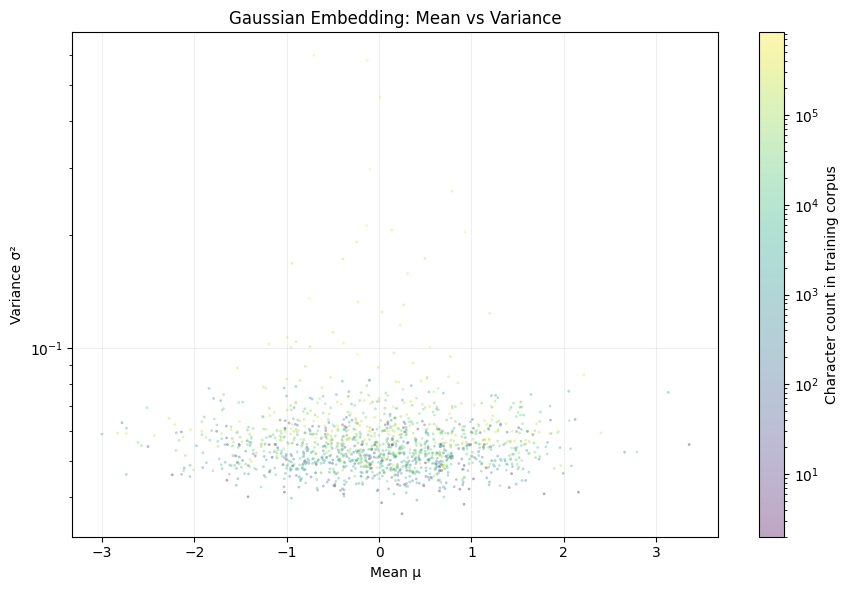

In [ ]:
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm

mu = model.embedding.mu.detach().cpu()
variance = model.embedding.std.detach().square().cpu()

# Give each of a character's embedding dimensions the same frequency colour.
counts = torch.bincount(tokens, minlength=mu.shape[0]).cpu()
point_counts = counts.repeat_interleave(mu.shape[1])

fig, ax = plt.subplots(figsize=(9, 6))
points = ax.scatter(
    mu.flatten().numpy(),
    variance.flatten().numpy(),
    c=point_counts.numpy(),
    cmap="viridis",
    norm=LogNorm(vmin=max(1, counts.min().item()), vmax=counts.max().item()),
    s=4,
    alpha=0.35,
    linewidths=0,
)

ax.set_yscale("log")
ax.set_xlabel("Mean μ")
ax.set_ylabel("Variance σ²")
ax.set_title("Gaussian Embedding: Mean vs Variance")
ax.grid(alpha=0.2)
fig.colorbar(points, ax=ax, label="Character count in training corpus")
plt.tight_layout()
plt.show()


In [ ]:
# Fixed training blocks make checkpoint comparisons repeatable.
diagnostic_generator = torch.Generator().manual_seed(1234)
diagnostic_indices = torch.randperm(len(loader.dataset), generator=diagnostic_generator)[:64]
diagnostic_blocks = torch.stack([loader.dataset[i] for i in diagnostic_indices])

@torch.no_grad()
def reconstruction_diagnostics(blocks=diagnostic_blocks, seed=1234):
    was_training = model.training
    model.eval()
    try:
        ids = blocks.to(device)
        generator = torch.Generator().manual_seed(seed)
        noise = lambda shape: torch.randn(shape, generator=generator).to(device)
        x0 = model.embedding.mu[ids] + model.embedding.std[ids] * noise((*ids.shape, DIM))
        rows = []
        for timestep in (1, 100, 500, 800, 1000):
            t = torch.full(ids.shape, timestep, dtype=torch.long, device=device)
            x_t = q_sample(x0, t, noise(x0.shape))
            prediction = model(x_t, t)
            log_probs = model.rounding_log_probs(prediction)
            rows.append((timestep, F.nll_loss(log_probs.flatten(0, 1), ids.flatten()).item(),
                         (log_probs.argmax(-1) == ids).float().mean().item(),
                         prediction.square().mean().item()))
        return rows
    finally:
        model.train(was_training)

@torch.no_grad()
def context_diagnostic(blocks=diagnostic_blocks, seed=1234):
    was_training = model.training
    model.eval()
    try:
        ids = blocks.to(device)
        generator = torch.Generator().manual_seed(seed)
        noise = torch.randn((*ids.shape, DIM), generator=generator).to(device)
        x0 = model.embedding.mu[ids] + model.embedding.std[ids] * noise
        target = torch.zeros(ids.shape, dtype=torch.bool, device=device)
        target[:, 3::8] = True
        t = torch.where(target, 500, 1)
        noise = torch.randn(x0.shape, generator=generator).to(device)
        x_t = q_sample(x0, t, noise)
        original = model.rounding_log_probs(model(x_t, t))
        permutation = torch.randperm(len(ids), generator=generator).to(device)
        shuffled = x_t.clone()
        shuffled[:, ~target[0]] = x_t[permutation][:, ~target[0]]
        changed = model.rounding_log_probs(model(shuffled, t))
        return (F.nll_loss(original[target], ids[target]).item(),
                F.nll_loss(changed[target], ids[target]).item())
    finally:
        model.train(was_training)

for timestep, ce, accuracy, norm in reconstruction_diagnostics():
    print(f't={timestep:4d} | ce={ce:.4f} | accuracy={accuracy:.1%} | raw_norm²/d={norm:.3f}')
original_ce, shuffled_ce = context_diagnostic()
print(f't=500 with clean neighbors | ce={original_ce:.4f} | shuffled={shuffled_ce:.4f}')


t=   1 | ce=0.0001 | accuracy=100.0% | raw_norm²/d=0.666
t= 100 | ce=0.0013 | accuracy=100.0% | raw_norm²/d=0.616
t= 500 | ce=2.7288 | accuracy=28.5% | raw_norm²/d=0.735
t= 800 | ce=3.2862 | accuracy=16.3% | raw_norm²/d=0.741
t=1000 | ce=3.2987 | accuracy=16.3% | raw_norm²/d=0.741
t=500 with clean neighbors | ce=2.7420 | shuffled=2.8033


In [ ]:
print('Reverse trajectory:')
for row in sample(reverse_steps=50, trace=True, seed=12).cpu().tolist():
    print(repr(''.join(chars[i] for i in row)))


Reverse trajectory:
1/50 | t=1000 -> 946 | raw_norm²/d=0.741 | x0_norm²/d=0.006 | state_norm²/d=0.950
25/50 | t=248 -> 233 | raw_norm²/d=0.672 | x0_norm²/d=0.675 | state_norm²/d=0.906
45/50 | t=59 -> 52 | raw_norm²/d=0.667 | x0_norm²/d=0.867 | state_norm²/d=0.919
50/50 | t=20 -> 0 | raw_norm²/d=0.663 | x0_norm²/d=0.917 | state_norm²/d=0.917
'   asn we mtnoiannyttfr agtnl -   ime\nll   kb oeosnenoo o!tdael\n'
're rmtitee g ? Bcngiif hdhulr,tn nyyhorrsk  m\nMoUhh\nt ofhhrmhmla'


In [ ]:
checkpoint_path = Path('checkpoints/gauss_embed_dlm_mmd_token_time.pt')
checkpoint_path.parent.mkdir(parents=True, exist_ok=True)
torch.save({'model': model.state_dict(), 'chars': chars}, checkpoint_path)
